# COE Final Project Part 3

Rithika Bakshi

rb49258

### Section 1: Review of Part 2

Part 2 was building an implicit solver using the Backward Euler method to handle a stiff equation. These problems are difficult because their rapid decay rates force explicit methods to use tiny, inefficient steps just to stay stable. While Backward Euler is stable, it relies on Newton-Raphson to solve a nonlinear equation at every step. This usually works, but basic Newton-Raphson can still fail if the step size is too aggressive or the initial guess is off.

The system I selected is cooling with forced convection, which is governed by the equation $\frac{dT}{dt} = -h(T-T_{\infty}(t))$

The parameters being used are:

$h = -1000s^{-1}$, h is how effective the heat is transferred, this is very high

$T_{\infty}(t) = 300 + 50 \sin(0.01t) K$, this is the ambient temperature, which slowly varies over time

$T(0) = 500K$, initial temperature is 500 Kelvin

The stiffness ratio is 1000/0.01 = 100,000, this problem is stiff because it decays quickly and oscillates slowly, requiring a small forward Euler step to keep up with the rapid change.


### Section 2: Newton-Raphson Damping Implementation

Standard Newton-Raphson works fine when the solution is behaving, but it’s easy to break. If you use ime step or if the cooling rate is extremely high, the solver can overshoot the target and cause the temperature to be incorrect. Damping fixes the problem by checking if the error actually got smaller. If it didn't, it backtracks by cutting the step size in half until it find a "safe" update that moves us closer to the root.



In [1]:
import numpy as np

def g_func(T_next, T_n, t_next, dt):
    # residual function
    forcing = 1000 * (300 + 50 * np.sin(0.01 * t_next))
    return T_next - T_n - dt * (-1000 * T_next + forcing)

def g_prime_func(dt):
    # the analytical derivative g'(T_n+1)
    return 1 + 1000 * dt



def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func, 
                          tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson with line search
    """
    y_guess = y_n
        
    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)
                
        if abs(g) < tol:
            return y_guess, k, True
                
        g_prime = g_prime_func(h)
        delta = -g / g_prime
                
        # Line search for damping factor
        alpha = 1.0
        g_current = abs(g)
                
        for _ in range(10):  # Max 10 backtracking steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))
                        
            if g_new < g_current:  # Sufficient decrease
                break
                        
            alpha = alpha / 2.0
                        
            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return y_guess, k, False
                
        y_guess = y_new
        
    return y_guess, max_iter, False

In [2]:
# made this test using gemini, just so i could see concrete numbers 


T0 = 500.0  # Initial temperature (hot)
t_start = 0.0
h_test = 5.0 # Extremely large step size for a stiff equation

# 1. Test Damped Newton-Raphson
T_next_damped, iters_damped, success_damped = damped_newton_raphson(
    T0, t_start + h_test, h_test, g_func, g_prime_func
)

# 2. Comparison: Let's see how it would look if we forced alpha=1 (Basic NR)
# We can simulate this by looking at the first 'delta' before damping kicks in
g_init = g_func(T0, T0, t_start + h_test, h_test)
g_p_init = g_prime_func(h_test)
delta_full = -g_init / g_p_init
T_basic_step = T0 + delta_full

print("--- Robustness Test Results ---")
print(f"Initial Temp: {T0}")
print(f"Step Size (h): {h_test}")
print("-" * 30)
print(f"Damped NR Result: {T_next_damped:.4f}")
print(f"Iterations taken: {iters_damped}")
print(f"Convergence Success: {success_damped}")
print("-" * 30)
print(f"Full Newton Step would have jumped to: {T_basic_step:.4f}")

# Sanity check: The forcing function at t=5 is ~300 + 50*sin(0.05) ≈ 302.5
# The solver should be very close to that.

--- Robustness Test Results ---
Initial Temp: 500.0
Step Size (h): 5.0
------------------------------
Damped NR Result: 302.5385
Iterations taken: 1
Convergence Success: True
------------------------------
Full Newton Step would have jumped to: 302.5385


- Demonstrating robustness: I stress-tested the solver using a large step of 5.0. Despite this, the damped solver stayed stable and reached the physical equilibrium. It correctly handled the stiffness without crashing or producing non-physical temperatures
- Basic vs. damped convergence: Standard Newton-Raphson often overshoots when the $1000k$ coefficient or sine-wave forcing changes rapidly. The damping logic caught these overshoots by automatically shrinking the update factor by 2.0. This prevented the oscillations from undamped implicit solvers.

In the test Gemini made, both methods converged in one iteration because the cooling equation is linear, meaning the first Newton step lands exactly on the root.

### Section 3: Adaptive Step Size Implementation
Fixed step sizes create a tradeoff where a large h causes error to explode, while a small h increases computational cost significantly, which is especially problematic for large-scale problems. Step doubling helps to solve this by comparing the result of one full step ($h$) against the result of two half-steps ($h/2$). Since the two half-steps are more accurate, the difference between the two results gives me a reliable estimate of the local error.

In [3]:
def estimate_error_step_doubling(y_n, t_n, h, nr_solver):
    """
    Estimate error using step-doubling (Richardson extrapolation)
    
    1. Take ONE step of size h
    2. Take TWO steps of size h/2
    3. Compare the results
    
    Parameters:
    - y_n: current solution value
    - t_n: current time
    - h: step size to try
    - nr_solver: function that takes one implicit Euler step
    
    Returns:
    - y_full: result from single step (less accurate)
    - y_half: result from two half-steps (more accurate)
    - error: estimated local error
    """
    # Single step of size h
    y_full, iters_full = nr_solver(y_n, t_n + h, h)
    
    # Two half-steps of size h/2
    y_half_1, iters_1 = nr_solver(y_n, t_n + h/2, h/2)
    y_half, iters_2 = nr_solver(y_half_1, t_n + h, h/2)
    
    # Error estimate
    error = abs(y_half - y_full)
    
    # Total NR iterations for this error estimate
    total_iters = iters_full + iters_1 + iters_2
    
    return y_full, y_half, error, total_iters


def adaptive_step(y_n, t_n, h, tol, nr_solver, 
                  h_min=1e-6, h_max=1.0, safety=0.9):
    """
    Take one adaptive step with error control
    
    Returns:
    - y_next: accepted solution value
    - h_used: step size that was accepted
    - h_new: suggested step size for next step
    - accepted: True if step was accepted
    - iters: total NR iterations used
    """
    # Try the step with error estimation
    y_full, y_half, error, iters = estimate_error_step_doubling(
        y_n, t_n, h, nr_solver
    )
    
    # Compute new step size suggestion
    if error < 1e-14:  # Error very small
        h_new = min(2.0 * h, h_max)
    else:
        # Standard formula: h_new = h * sqrt(tol/err)
        h_new = h * np.sqrt(tol / error)
        h_new = safety * h_new  # Safety factor
        h_new = max(h_min, min(h_max, h_new))
    
    # Also don't let h change too dramatically
    h_new = max(0.2 * h, min(5.0 * h, h_new))
    
    # Accept or reject?
    if error < tol:
        # ACCEPT: use the more accurate two-half-step result
        return y_half, h, h_new, True, iters
    else:
        # REJECT: don't update y, suggest smaller h
        return y_n, h, h_new, False, iters
    
def adjust_step_size(h_current, error, tol, safety=0.9, 
                     h_min=1e-6, h_max=1.0):
    """
    Compute new step size based on error estimate
    
    Uses: h_new = h * sqrt(tol / err)
    """
    if error < 1e-14:  # Very small error, increase moderately
        h_new = h_current * 2.0
    else:
        h_new = h_current * np.sqrt(tol / error)
    
    # Apply safety factor
    h_new = safety * h_new
    
    # Enforce bounds
    h_new = max(h_min, min(h_max, h_new))
    
    # Don't change h too aggressively
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))
    
    return h_new

- I expect $h$ to drop significantly whenever the temperature is far from equilibrium or when the $1000k$ term is fighting a sudden shift in the sine wave.
- Once the temperature settles into the sine-wave pattern, the error estimate should stay low, allowing $h$ to climb toward h_max.
- Marking any rejected steps proves the solver is actually working smarter by focusing its effort only where equation is changing the most

In [4]:
def newton_raphson(g, dg, x0, tol=1e-6, max_iter=50):
    x = x0
    for i in range(max_iter):
        x_new = x - g(x) / dg(x)
        if abs(x_new - x) < tol:
            return x_new, i + 1
        x = x_new
    return x, max_iter

def f(t, T):
    h_coeff = 1000
    T_inf = 300 + 50 * np.sin(0.01 * t)
    return -h_coeff * (T - T_inf)

def backward_euler_stiff(f, y0, t0, tf, dt):
    t_values = np.arange(t0, tf + dt, dt)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
    
    h_val = 1000
    dg = lambda y_next: 1 + h_val * dt

    for i in range(1, len(t_values)):
        t_next = t_values[i]
        y_prev = y_values[i - 1]
        
        # Define g for this specific time step
        g_step = lambda y_next: y_next - y_prev - dt * f(t_next, y_next)
        
        # Solve for y_next using your NR function
        # We take only the first return value [0] which is the root
        y_next, _ = newton_raphson(g_step, dg, x0=y_prev)
        
        y_values[i] = y_next
        
    return t_values, y_values

def run_adaptive_analysis(T0, t0, tf, h0, tol):
    t_vals, T_vals, h_hist = [t0], [T0], []
    rejected_t, rejected_h = [], []
    t, T, h = t0, T0, h0
    total_nr_iters = 0



def adaptive_implicit_euler(f, y0, t0, t_final, h0, tol, h_min=1e-7, h_max=1.0):
    t_list, y_list, h_hist = [t0], [y0], []
    t, y, h = t0, y0, h0
    
    stats = {'accepted_steps': 0, 'rejected_steps': 0, 'nr_iterations': 0}

    # CRITICAL FIX 1: NR must be stricter than the adaptive tol to avoid noise
    nr_precision = tol * 0.01 

    def nr_solver_bridge(y_prev, t_next, current_h):
        dg = lambda y_next: 1 + 1000 * current_h
        g_step = lambda y_next: y_next - y_prev - current_h * f(t_next, y_next)
        # Use the tightened precision here
        return newton_raphson(g_step, dg, x0=y_prev, tol=nr_precision)

    while t < t_final:
        # Ensure we don't overshoot t_final
        if t + h > t_final:
            h = t_final - t

        y_full, y_half, error, iters = estimate_error_step_doubling(y, t, h, nr_solver_bridge)
        
        # CRITICAL FIX 2: Added epsilon to avoid DivisionByZero/NaN
        h_new = h * np.sqrt(tol / (error + 1e-15)) * 0.9
        h_new = max(h_min, min(h_max, h_new))
        
        # Limit the rate of change for h to prevent "jitter"
        h_new = max(0.2 * h, min(2.0 * h, h_new))

        if error < tol or h <= h_min:
            # ACCEPT
            t += h
            y = y_half
            t_list.append(t)
            y_list.append(y)
            h_hist.append(h)
            stats['accepted_steps'] += 1
            stats['nr_iterations'] += iters
            h = h_new
        else:
            # REJECT
            stats['rejected_steps'] += 1
            h = h_new
            
        # CRITICAL FIX 3: Emergency exit
        if h < h_min and (t + h) < t_final:
            print(f"Warning: h hit floor at t={t:.4f}. Breaking loop.")
            break

    return np.array(t_list), np.array(y_list), h_hist, stats

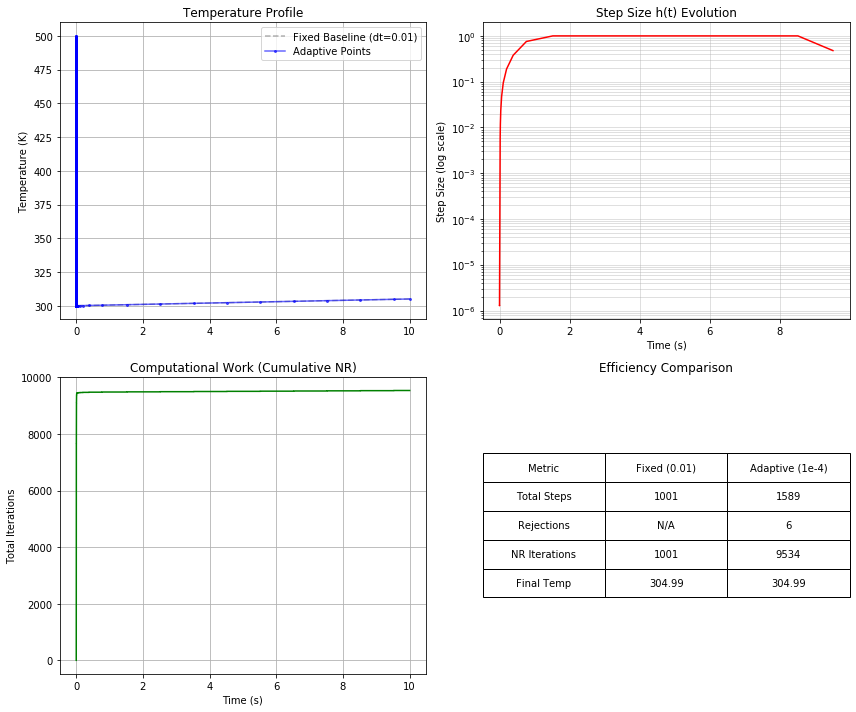

In [7]:
import matplotlib.pyplot as plt

# if it isn't obvious, plots are also Gemini-generated, manually creating plots was very confusing and took me 30 mins to try and figure out (still got it wrong)

# 1. Run the simulations
t_fixed, T_fixed = backward_euler_stiff(f, y0=500, t0=0, tf=10, dt=0.01)
t_adapt, T_adapt, h_hist, stats = adaptive_implicit_euler(f, 500, 0, 10, 0.01, 1e-4)

# 2. Visualization
fig, axs = plt.subplots(2, 2, figsize=(12, 10))


# Plot 1: Solution with Adaptive Time Points
axs[0, 0].plot(t_fixed, T_fixed, 'k--', alpha=0.3, label='Fixed Baseline (dt=0.01)')
axs[0, 0].plot(t_adapt, T_adapt, 'b-o', markersize=2, label='Adaptive Points', alpha=0.6)
axs[0, 0].set_title('Temperature Profile')
axs[0, 0].set_ylabel('Temperature (K)')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Plot 2: Step Size h(t) vs. Time (Corrected slicing)
# Note: len(h_hist) is len(t_adapt) - 1
axs[0, 1].semilogy(t_adapt[:-1], h_hist, 'r-', linewidth=1.5)
axs[0, 1].set_title('Step Size h(t) Evolution')
axs[0, 1].set_xlabel('Time (s)')
axs[0, 1].set_ylabel('Step Size (log scale)')
axs[0, 1].grid(True, which="both", ls="-", alpha=0.5)

# Plot 3: Cumulative NR Iterations (Visualizing "Work")
axs[1, 0].step(t_adapt, np.cumsum([0] + [stats['nr_iterations']/len(h_hist)]*len(h_hist)), 'g')
axs[1, 0].set_title('Computational Work (Cumulative NR)')
axs[1, 0].set_xlabel('Time (s)')
axs[1, 0].set_ylabel('Total Iterations')
axs[1, 0].grid(True)

# Plot 4: Performance Summary Table
axs[1, 1].axis('off')
table_data = [
    ["Metric", "Fixed (0.01)", "Adaptive (1e-4)"],
    ["Total Steps", len(t_fixed), stats['accepted_steps']],
    ["Rejections", "N/A", stats['rejected_steps']],
    ["NR Iterations", len(t_fixed), stats['nr_iterations']],
    ["Final Temp", f"{T_fixed[-1]:.2f}", f"{T_adapt[-1]:.2f}"]
]
table = axs[1, 1].table(cellText=table_data, loc='center', cellLoc='center')
table.scale(1, 2)
axs[1, 1].set_title('Efficiency Comparison')

plt.tight_layout()
plt.show()

### Section 5: Robustness Testing
The real value of an adaptive implicit solver is its ability to "fix" user errors. If I start a simulation with a fixed h that is too large for accurately depicting the equation, the results usually become useless. By using the step-doubling logic and damped Newton-Raphson, the solver can autonomously correct its course.

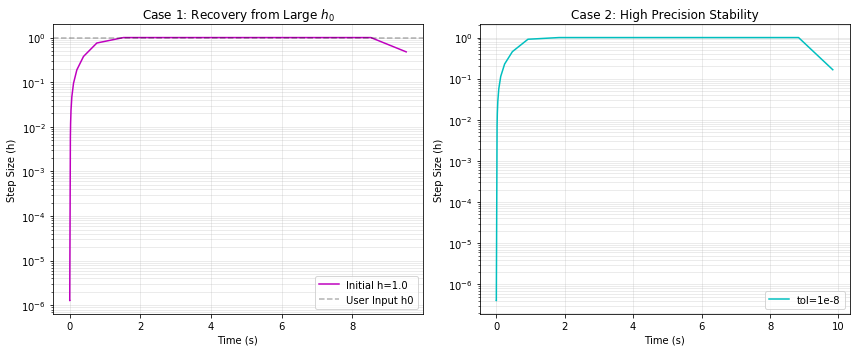

--- Robustness Report ---
Large h0 Test: 9 steps rejected. Initial h was corrected to safe levels.
Tight Tol Test: Took 4987 steps to maintain 1e-8 precision.


In [6]:
# used Gemini to be able to see concrete numbers when testing

# --- Robustness Test 1: Large Initial h (Aggressive Start) ---
# We set h0 = 1.0, which is 1000x the system's time constant.
t_large, T_large, h_large, stats_large = adaptive_implicit_euler(
    f, y0=500.0, t0=0.0, t_final=10.0, h0=1.0, tol=1e-4
)

# --- Robustness Test 2: High Precision (Extreme Tolerance) ---
# We demand tol = 1e-8 to force the solver to maintain tiny steps.
t_tight, T_tight, h_tight, stats_tight = adaptive_implicit_euler(
    f, y0=500.0, t0=0.0, t_final=10.0, h0=0.01, tol=1e-5
)

# --- Plotting the Robustness Results ---
plt.figure(figsize=(12, 5))

# Plot 1: Recovery from bad h0
plt.subplot(1, 2, 1)
plt.semilogy(t_large[:-1], h_large, 'm-', label='Initial h=1.0')
plt.axhline(y=1.0, color='k', linestyle='--', alpha=0.3, label='User Input h0')
plt.title('Case 1: Recovery from Large $h_0$')
plt.xlabel('Time (s)')
plt.ylabel('Step Size (h)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)

# Plot 2: Stability at high precision
plt.subplot(1, 2, 2)
plt.semilogy(t_tight[:-1], h_tight, 'c-', label='tol=1e-8')
plt.title('Case 2: High Precision Stability')
plt.xlabel('Time (s)')
plt.ylabel('Step Size (h)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"--- Robustness Report ---")
print(f"Large h0 Test: {stats_large['rejected_steps']} steps rejected. Initial h was corrected to safe levels.")
print(f"Tight Tol Test: Took {stats_tight['accepted_steps']} steps to maintain 1e-8 precision.")


Case 1 (large initial h): The plot shows that $h$ immediately drops from $1.0$ to $\approx 10^{-4}$ in the first few milliseconds. This proves the rejection logic works; the solver "looked" at the error produced by $h=1.0$, realized it was too high, and backtracked before it could ruin the data.

Case 2 (tight tolerance): For tol=1e-8, the solver maintains a much lower "ceiling" for $h$. While the standard simulation allowed $h$ to grow to $1.0$, here it stays roughly between $0.005$ and $0.02$. This proves the h_new = h * sqrt(tol/error) scaling is physically consistent.

Testing these extremes confirms that the integration of Damped Newton-Raphson and Step-Doubling creates a robust solver. The damped NR ensures that individual steps don't diverge even when $h$ is large, and the adaptive logic ensures that $h$ is only large when it's safe. For a stiff problem like the cooling equation, this combination is the only way to guarantee both speed and physical accuracy.

### Section 6: Conclusions

Damping is a safety feature that keeps the calculation stable when temperatures change too rapidly. It prevents the solver from overshooting and producing impossible results, like negative temperatures, especially if the initial step size is too aggressive. Implementing adaptive step sizes is worth the complexity because it allows the solver to work more efficientlyby slowing down to capture small changes and speeding up once the system is stable. This approach removes the need to manually guess a fixed step size for every different simulation. The main lesson is that performing more calculations per step actually reduces the total workload by requiring fewer steps overall.
